In [2]:
import pandas as pd
import matplotlib.pyplot as plt

application = pd.read_csv('application_train.csv')
previous = pd.read_csv('previous_application.csv')
bureau = pd.read_csv('bureau.csv')

In [3]:
print (application.shape)
print (application.head())
print(application.info())


(307511, 122)
   SK_ID_CURR  TARGET NAME_CONTRACT_TYPE CODE_GENDER FLAG_OWN_CAR  \
0      100002       1         Cash loans           M            N   
1      100003       0         Cash loans           F            N   
2      100004       0    Revolving loans           M            Y   
3      100006       0         Cash loans           F            N   
4      100007       0         Cash loans           M            N   

  FLAG_OWN_REALTY  CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  \
0               Y             0          202500.0    406597.5      24700.5   
1               N             0          270000.0   1293502.5      35698.5   
2               Y             0           67500.0    135000.0       6750.0   
3               Y             0          135000.0    312682.5      29686.5   
4               Y             0          121500.0    513000.0      21865.5   

   ...  FLAG_DOCUMENT_18 FLAG_DOCUMENT_19 FLAG_DOCUMENT_20 FLAG_DOCUMENT_21  \
0  ...                 

In [4]:
print (previous.shape)

print (previous.head())

(1670214, 37)
   SK_ID_PREV  SK_ID_CURR NAME_CONTRACT_TYPE  AMT_ANNUITY  AMT_APPLICATION  \
0     2030495      271877     Consumer loans     1730.430          17145.0   
1     2802425      108129         Cash loans    25188.615         607500.0   
2     2523466      122040         Cash loans    15060.735         112500.0   
3     2819243      176158         Cash loans    47041.335         450000.0   
4     1784265      202054         Cash loans    31924.395         337500.0   

   AMT_CREDIT  AMT_DOWN_PAYMENT  AMT_GOODS_PRICE WEEKDAY_APPR_PROCESS_START  \
0     17145.0               0.0          17145.0                   SATURDAY   
1    679671.0               NaN         607500.0                   THURSDAY   
2    136444.5               NaN         112500.0                    TUESDAY   
3    470790.0               NaN         450000.0                     MONDAY   
4    404055.0               NaN         337500.0                   THURSDAY   

   HOUR_APPR_PROCESS_START  ... NAME_SELLE

In [5]:
print (bureau.shape)

print (bureau.head())

(1716428, 17)
   SK_ID_CURR  SK_ID_BUREAU CREDIT_ACTIVE CREDIT_CURRENCY  DAYS_CREDIT  \
0      215354       5714462        Closed      currency 1         -497   
1      215354       5714463        Active      currency 1         -208   
2      215354       5714464        Active      currency 1         -203   
3      215354       5714465        Active      currency 1         -203   
4      215354       5714466        Active      currency 1         -629   

   CREDIT_DAY_OVERDUE  DAYS_CREDIT_ENDDATE  DAYS_ENDDATE_FACT  \
0                   0               -153.0             -153.0   
1                   0               1075.0                NaN   
2                   0                528.0                NaN   
3                   0                  NaN                NaN   
4                   0               1197.0                NaN   

   AMT_CREDIT_MAX_OVERDUE  CNT_CREDIT_PROLONG  AMT_CREDIT_SUM  \
0                     NaN                   0         91323.0   
1                   

In [6]:
application['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [7]:
application['TARGET'].value_counts(normalize=True)

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64

## Initial Findings

The dataset contains 307,511 loan applications.

Approximately 8.1% of applicants defaulted on their loans, while 91.9% successfully repaid.

This indicates a relatively imbalanced population where defaults represent a small but important portion of customers.

In [8]:
application[['SK_ID_CURR']].head()

,SK_ID_CURR
0,100002
1,100003
2,100004
3,100006
4,100007


In [9]:
application[['TARGET',
             'AMT_INCOME_TOTAL',
             'AMT_CREDIT',
             'AMT_ANNUITY',
             'NAME_EDUCATION_TYPE',
             'NAME_FAMILY_STATUS']].head()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS
0,1,202500.0,406597.5,24700.5,Secondary / secondary special,Single / not married
1,0,270000.0,1293502.5,35698.5,Higher education,Married
2,0,67500.0,135000.0,6750.0,Secondary / secondary special,Single / not married
3,0,135000.0,312682.5,29686.5,Secondary / secondary special,Civil marriage
4,0,121500.0,513000.0,21865.5,Secondary / secondary special,Single / not married


In [10]:
application[['TARGET',
             'AMT_INCOME_TOTAL',
             'AMT_CREDIT',
             'AMT_ANNUITY']].describe()

,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY
count,307511.000000,3.075110e+05,3.075110e+05,307499.000000
mean,0.080729,1.687979e+05,5.990260e+05,27108.573909
std,0.272419,2.371231e+05,4.024908e+05,14493.737315
min,0.000000,2.565000e+04,4.500000e+04,1615.500000
25%,0.000000,1.125000e+05,2.700000e+05,16524.000000
50%,0.000000,1.471500e+05,5.135310e+05,24903.000000
75%,0.000000,2.025000e+05,8.086500e+05,34596.000000
max,1.000000,1.170000e+08,4.050000e+06,258025.500000


In [11]:
application['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

In [12]:
education_risk = (
    application
    .groupby('NAME_EDUCATION_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=False)
)

education_risk

NAME_EDUCATION_TYPE
Lower secondary                  0.109277
Secondary / secondary special    0.089399
Incomplete higher                0.084850
Higher education                 0.053551
Academic degree                  0.018293
Name: TARGET, dtype: float64

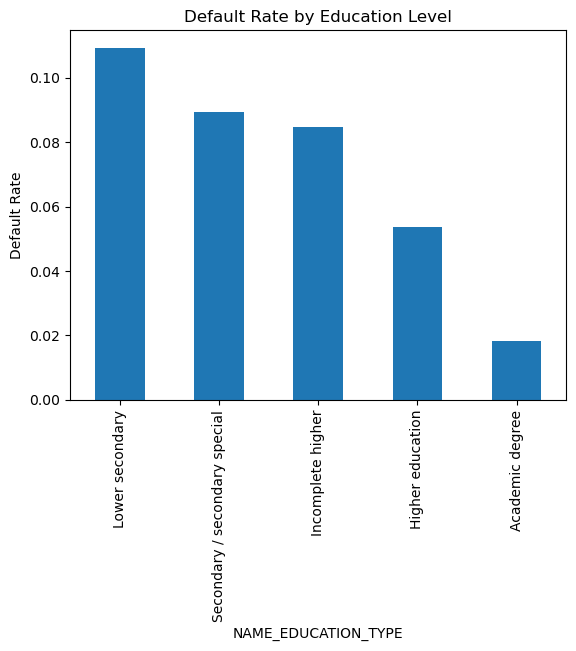

In [13]:
import matplotlib.pyplot as plt

education_risk.plot(kind='bar')

plt.title('Default Rate by Education Level')
plt.ylabel('Default Rate')
plt.show()

Default risk decreases as educational attainment increases. Applicants with academic degrees experienced the lowest default rates, while applicants with only lower secondary education exhibited the highest risk.

In [14]:
family_risk = (
    application
    .groupby('NAME_FAMILY_STATUS')['TARGET']
    .mean()
    .sort_values(ascending=False)
)

family_risk

NAME_FAMILY_STATUS
Civil marriage          0.099446
Single / not married    0.098077
Separated               0.081942
Married                 0.075599
Widow                   0.058242
Unknown                 0.000000
Name: TARGET, dtype: float64

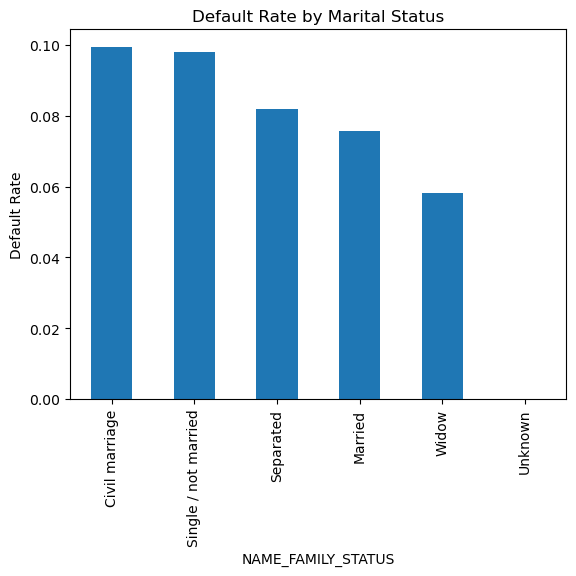

In [15]:
family_risk.plot(kind='bar')

plt.title('Default Rate by Marital Status')
plt.ylabel('Default Rate')
plt.show()

In [16]:
application['income_group'] = pd.qcut(
    application['AMT_INCOME_TOTAL'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\3787265257.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['income_group'] = pd.qcut(


In [17]:
application.groupby('income_group')['TARGET'].mean()

income_group
Very Low     0.082062
Low          0.085883
Medium       0.086847
High         0.080569
Very High    0.065198
Name: TARGET, dtype: float64

Applicants in the highest income group exhibited the lowest default rate (6.5%), while middle-income applicants showed the highest default rate (8.7%). This suggests higher income may be associated with lower credit risk.

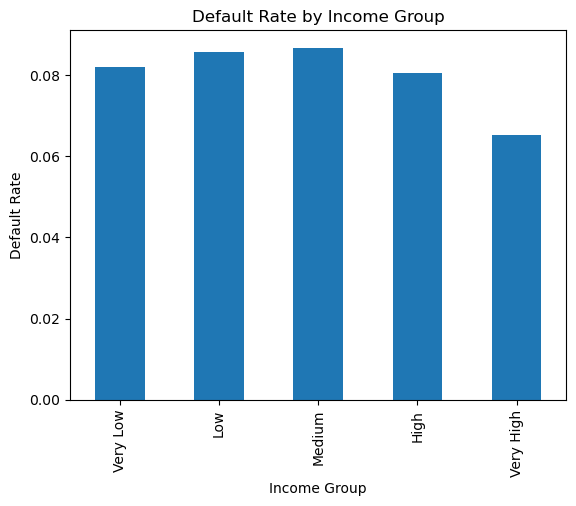

In [18]:
income_risk = (
    application
    .groupby('income_group')['TARGET']
    .mean()
)

income_risk.plot(kind='bar')

plt.title('Default Rate by Income Group')
plt.ylabel('Default Rate')
plt.xlabel('Income Group')

plt.show()

### Income and Default Risk

Applicants in the highest income group exhibited the lowest default rate (6.5%), while middle-income applicants showed the highest default rate (8.7%).

This suggests that higher income levels may be associated with lower credit risk, although the relationship is not perfectly linear across all income groups.

In [19]:
application[['AMT_INCOME_TOTAL', 'income_group']].head()

,AMT_INCOME_TOTAL,income_group
0,202500.0,High
1,270000.0,Very High
2,67500.0,Very Low
3,135000.0,Low
4,121500.0,Low


# Loan Risk Factors

This section analyzes financial and borrower characteristics that may influence credit default risk, including in

In [20]:
#Loan to Income Ratio

application['loan_income_ratio']= (application['AMT_CREDIT'] / application['AMT_INCOME_TOTAL'])

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\46058937.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['loan_income_ratio']= (application['AMT_CREDIT'] / application['AMT_INCOME_TOTAL'])


In [21]:
application['ratio_group'] = pd.qcut(
    application['loan_income_ratio'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\2527999931.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['ratio_group'] = pd.qcut(


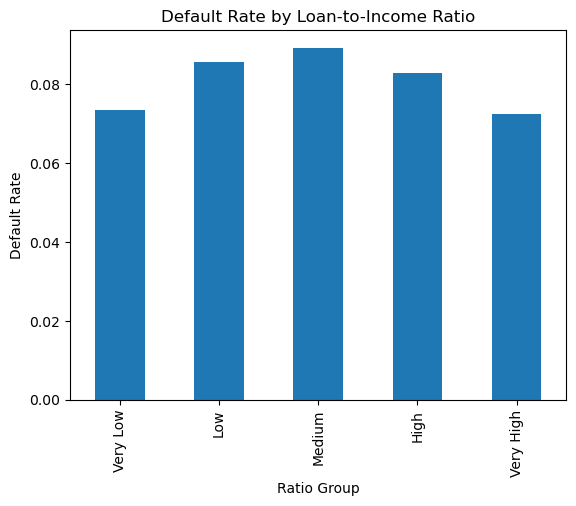

In [22]:
ratio_risk = (
    application
    .groupby('ratio_group')['TARGET']
    .mean()
)

ratio_risk.plot(kind='bar')

plt.title('Default Rate by Loan-to-Income Ratio')
plt.ylabel('Default Rate')
plt.xlabel('Ratio Group')
plt.show()

In [23]:
#Employment Lenght
import numpy as np
application['DAYS_EMPLOYED']
# Replace fake employment value with missing
application['DAYS_EMPLOYED_CLEAN'] = application['DAYS_EMPLOYED'].replace(365243, np.nan)


C:\Users\15712\AppData\Local\Temp\ipykernel_42684\4144602690.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['DAYS_EMPLOYED_CLEAN'] = application['DAYS_EMPLOYED'].replace(365243, np.nan)


In [24]:
# Convert days employed into years
application['years_employed'] = (
    application['DAYS_EMPLOYED_CLEAN'].abs() / 365
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\833267246.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['years_employed'] = (


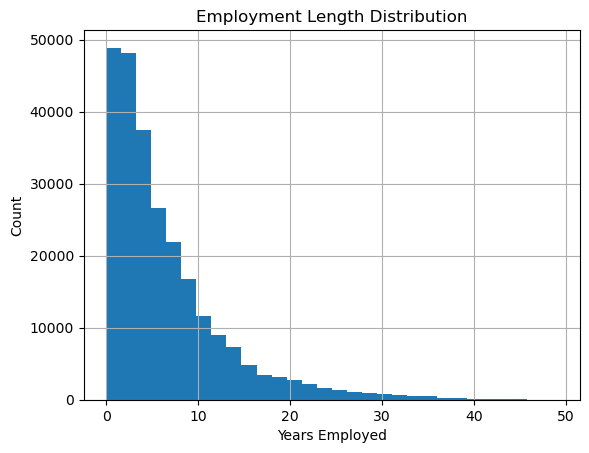

In [25]:
application['years_employed'].hist(bins=30)

plt.title('Employment Length Distribution')
plt.xlabel('Years Employed')
plt.ylabel('Count')
plt.show()

In [26]:
application['employment_group'] = pd.cut(
    application['years_employed'],
    bins=[0, 2, 5, 10, 20, 50],
    labels=[
        '0-2 Years',
        '2-5 Years',
        '5-10 Years',
        '10-20 Years',
        '20+ Years'
    ]
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\2314625255.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['employment_group'] = pd.cut(


In [27]:
employment_risk = (
    application
    .groupby('employment_group')['TARGET']
    .mean() * 100
)

employment_risk

employment_group
0-2 Years      11.201003
2-5 Years      10.077925
5-10 Years      7.371439
10-20 Years     5.513308
20+ Years       4.189232
Name: TARGET, dtype: float64

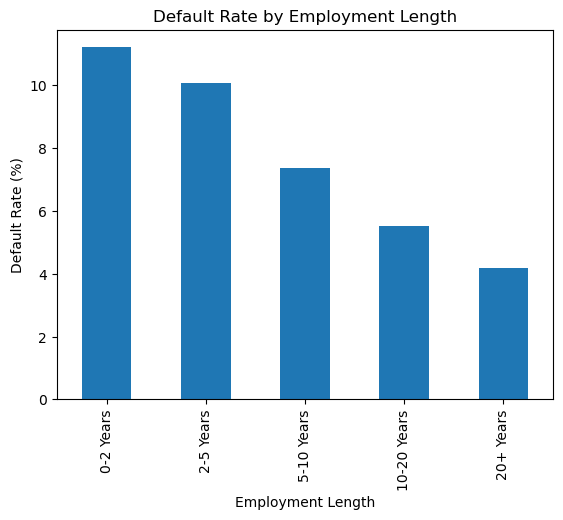

In [28]:
employment_risk.plot(kind='bar')

plt.title('Default Rate by Employment Length')
plt.xlabel('Employment Length')
plt.ylabel('Default Rate (%)')
plt.show()

In [29]:
#Age Analysis
application['DAYS_BIRTH']

0         -9461
1        -16765
2        -19046
3        -19005
4        -19932
          ...  
307506    -9327
307507   -20775
307508   -14966
307509   -11961
307510   -16856
Name: DAYS_BIRTH, Length: 307511, dtype: int64

In [30]:
application['age'] = (
    application['DAYS_BIRTH'].abs() / 365
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\3369773362.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['age'] = (


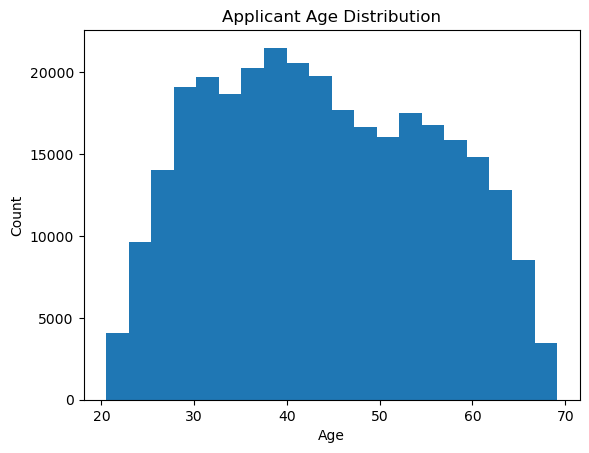

In [31]:
plt.hist(application['age'], bins=20)

plt.title('Applicant Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

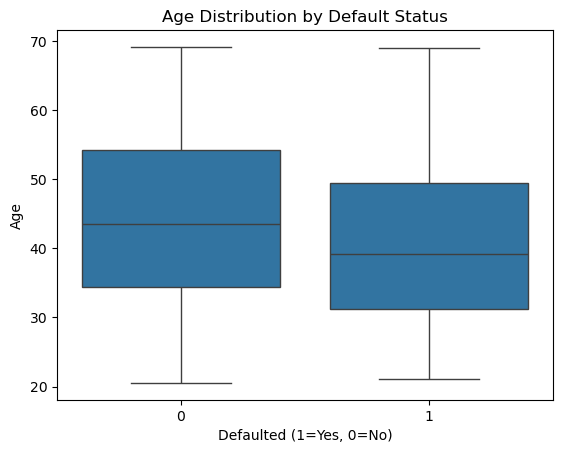

In [32]:
import seaborn as sns

sns.boxplot(
    data=application,
    x='TARGET',
    y='age'
)

plt.title('Age Distribution by Default Status')
plt.xlabel('Defaulted (1=Yes, 0=No)')
plt.ylabel('Age')
plt.show()

In [33]:
application['age_group'] = pd.cut(
    application['age'],
    bins=[20,30,40,50,60,70],
    labels=[
        '20-30',
        '30-40',
        '40-50',
        '50-60',
        '60-70'
    ]
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\4092145767.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['age_group'] = pd.cut(


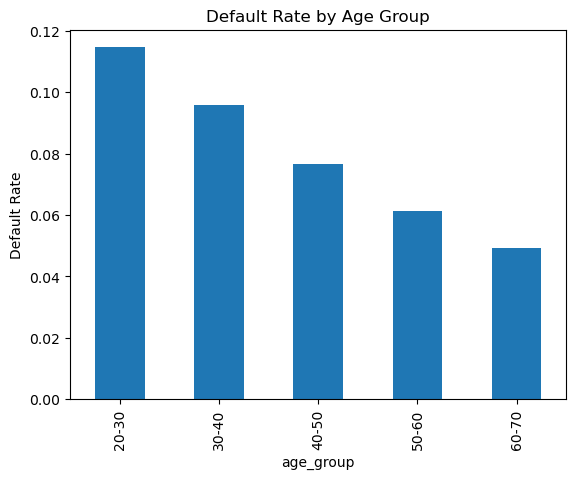

In [34]:
age_risk = application.groupby('age_group')['TARGET'].mean()

age_risk.plot(kind='bar')

plt.title('Default Rate by Age Group')
plt.ylabel('Default Rate')
plt.show()

In [35]:
#Credit Amount vs Default Risk
application['credit_group'] = pd.qcut(
    application['AMT_CREDIT'],
    q=5,
    labels=[
        'Very Low',
        'Low',
        'Medium',
        'High',
        'Very High'
    ]
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\3532306472.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['credit_group'] = pd.qcut(


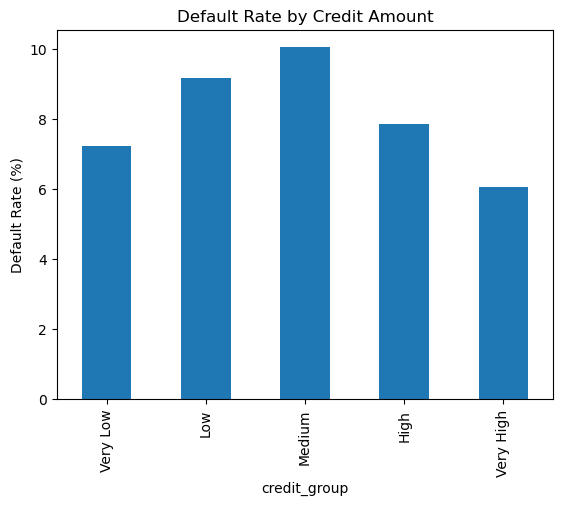

In [36]:
credit_risk = (
    application
    .groupby('credit_group')['TARGET']
    .mean() * 100
)

credit_risk.plot(kind='bar')

plt.title('Default Rate by Credit Amount')
plt.ylabel('Default Rate (%)')
plt.show()

In [37]:
#Annuity Burden
application['annuity_income_ratio'] = (
    application['AMT_ANNUITY']
    /
    application['AMT_INCOME_TOTAL']
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\1711768233.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['annuity_income_ratio'] = (


In [38]:
application['annuity_group'] = pd.qcut(
    application['annuity_income_ratio'],
    q=5,
    labels=[
        'Very Low Burden',
        'Low Burden',
        'Moderate Burden',
        'High Burden',
        'Very High Burden'
    ]
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\717353868.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application['annuity_group'] = pd.qcut(


In [39]:
annuity_risk = (
    application
    .groupby('annuity_group')['TARGET']
    .mean() * 100
)

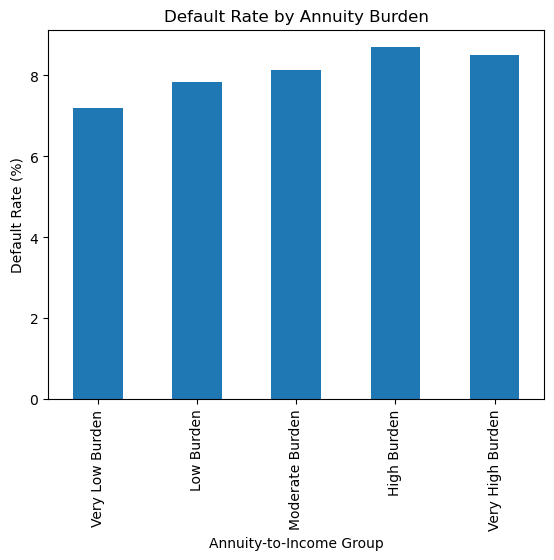

In [40]:
annuity_risk.plot(kind='bar')

plt.title('Default Rate by Annuity Burden')
plt.xlabel('Annuity-to-Income Group')
plt.ylabel('Default Rate (%)')
plt.show()

In [41]:
#Home Ownership
application['NAME_HOUSING_TYPE'].value_counts()


NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

<Axes: xlabel='NAME_HOUSING_TYPE'>

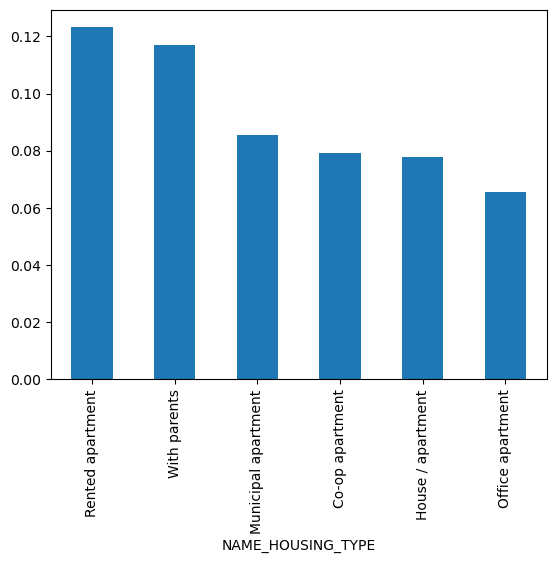

In [42]:
housing_risk = (
    application
    .groupby('NAME_HOUSING_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=False)
)

housing_risk.plot(kind='bar')

In [43]:
#Occupation Type
application['OCCUPATION_TYPE'].value_counts()

OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

In [44]:
occupation_risk = (
    application
    .groupby('OCCUPATION_TYPE')['TARGET']
    .mean()
    .sort_values(ascending=False)
    * 100
)

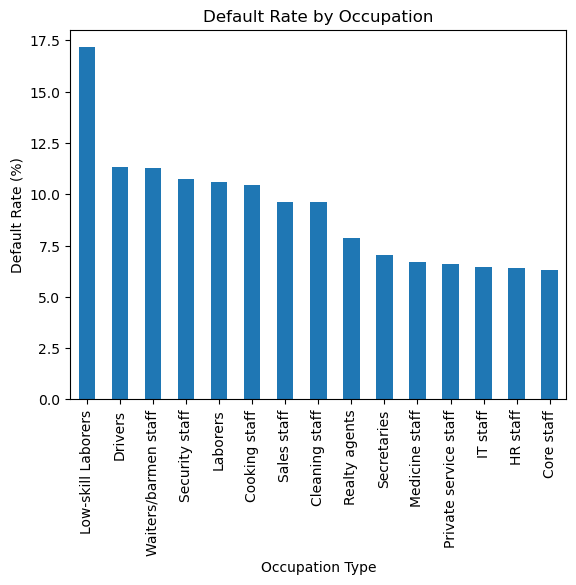

In [45]:
occupation_risk.head(15).plot(kind='bar')

plt.title('Default Rate by Occupation')
plt.xlabel('Occupation Type')
plt.ylabel('Default Rate (%)')
plt.show()

Laborers, drivers, and low-skilled labor occupations exhibited higher default rates, while managers and professional occupations generally demonstrated lower risk.

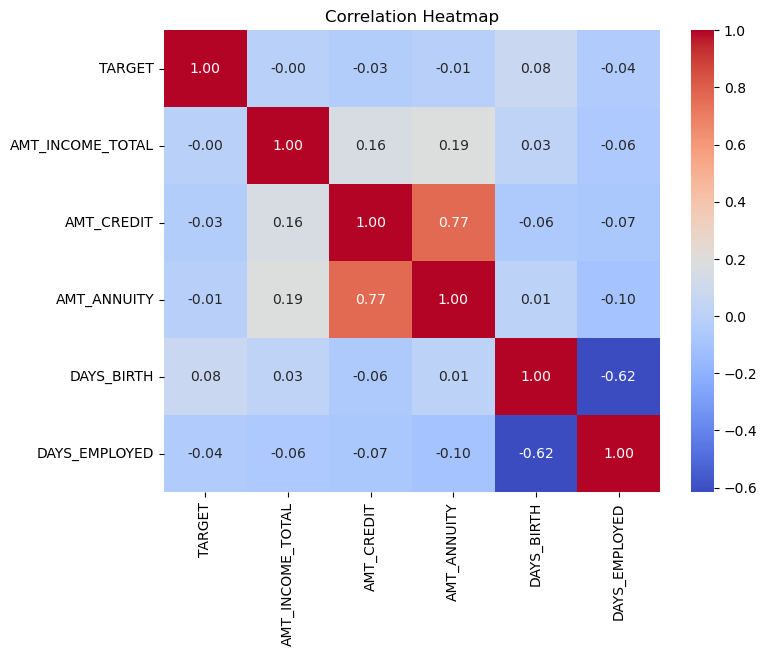

In [46]:
corr_cols = [
    'TARGET',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'DAYS_BIRTH',
    'DAYS_EMPLOYED'
]

corr = application[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

Correlations between individual numeric variables and default risk were generally weak, suggesting that credit risk is influenced by a combination of factors rather than a single variable.

In [47]:
missing = (
    application.isnull()
    .mean()
    .sort_values(ascending=False)
    * 100
)

missing.head(15)

COMMONAREA_MEDI             69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_AVG              69.872297
NONLIVINGAPARTMENTS_AVG     69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_MEDI    69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MODE       68.354953
LIVINGAPARTMENTS_MEDI       68.354953
FLOORSMIN_AVG               67.848630
FLOORSMIN_MEDI              67.848630
FLOORSMIN_MODE              67.848630
YEARS_BUILD_AVG             66.497784
YEARS_BUILD_MEDI            66.497784
dtype: float64

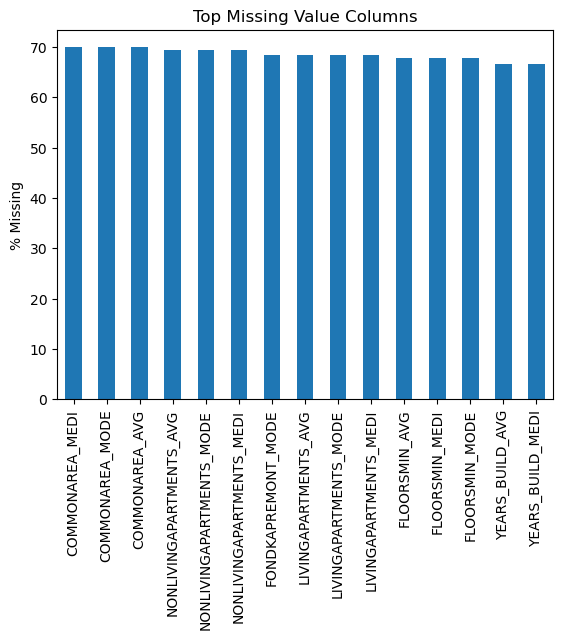

In [48]:
missing.head(15).plot(kind='bar')
plt.title('Top Missing Value Columns')
plt.ylabel('% Missing')
plt.show()

## Missing Values Analysis

Several housing-related variables contained substantial missing data, with many columns exceeding 65% missing values.

Because these variables contained limited usable information for a large portion of applicants, they may require imputation, feature engineering, or removal during model preparation.

This highlights a common challenge in real-world credit risk datasets where data completeness varies significantly across features.

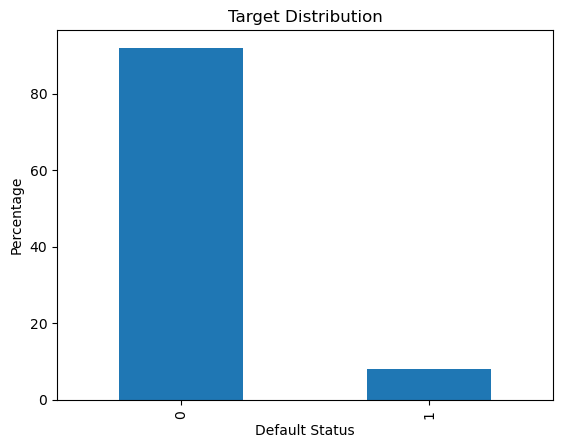

In [49]:
target_rate = application['TARGET'].value_counts(normalize=True) * 100

target_rate.plot(kind='bar')

plt.title('Target Distribution')
plt.ylabel('Percentage')
plt.xlabel('Default Status')
plt.show()

The target variable is highly imbalanced, with approximately 8% of applicants defaulting and 92% not defaulting.

This class imbalance will require special consideration during model development, including evaluation metrics beyond accuracy and potentially resampling techniques such as SMOTE.

## Key Findings

- Higher educational attainment was associated with lower default rates.
- Applicants with larger annuity burdens exhibited higher default risk.
- Income showed a modest relationship with default behavior, with higher-income applicants generally presenting lower risk.
- Certain occupations displayed elevated default rates compared to others.
- Individual numeric variables demonstrated weak correlations with default risk, suggesting that credit risk depends on multiple interacting factors.
- The dataset contains substantial missing values in several housing-related variables.
- The target variable is highly imbalanced, with approximately 8% defaults.

In [50]:
# Bureau features: customer's external credit history
bureau_features = bureau.groupby('SK_ID_CURR').agg(
    bureau_loan_count=('SK_ID_BUREAU', 'count'),
    active_loan_count=('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    closed_loan_count=('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),
    total_external_credit=('AMT_CREDIT_SUM', 'sum'),
    avg_days_credit=('DAYS_CREDIT', 'mean'),
    max_overdue_days=('CREDIT_DAY_OVERDUE', 'max')
).reset_index()

bureau_features.head()

,SK_ID_CURR,bureau_loan_count,active_loan_count,closed_loan_count,total_external_credit,avg_days_credit,max_overdue_days
0,100001,7,3,4,1453365.000,-735.000000,0
1,100002,8,2,6,865055.565,-874.000000,0
2,100003,4,1,3,1017400.500,-1400.750000,0
3,100004,2,0,2,189037.800,-867.000000,0
4,100005,3,2,1,657126.000,-190.666667,0


In [51]:
# Previous application features: customer's prior Home Credit activity
previous_features = previous.groupby('SK_ID_CURR').agg(
    previous_application_count=('SK_ID_PREV', 'count'),
    approved_application_count=('NAME_CONTRACT_STATUS', lambda x: (x == 'Approved').sum()),
    refused_application_count=('NAME_CONTRACT_STATUS', lambda x: (x == 'Refused').sum()),
    avg_previous_credit=('AMT_CREDIT', 'mean'),
    avg_previous_application_amount=('AMT_APPLICATION', 'mean')
).reset_index()

previous_features.head()

,SK_ID_CURR,previous_application_count,approved_application_count,refused_application_count,avg_previous_credit,avg_previous_application_amount
0,100001,1,1,0,23787.00,24835.50
1,100002,1,1,0,179055.00,179055.00
2,100003,3,3,0,484191.00,435436.50
3,100004,1,1,0,20106.00,24282.00
4,100005,2,1,0,20076.75,22308.75


In [52]:
application_enriched = application.merge(
    bureau_features,
    on='SK_ID_CURR',
    how='left'
)

application_enriched = application_enriched.merge(
    previous_features,
    on='SK_ID_CURR',
    how='left'
)

application_enriched.shape

(307511, 144)

In [53]:
joined_count_cols = [
    'bureau_loan_count',
    'active_loan_count',
    'closed_loan_count',
    'previous_application_count',
    'approved_application_count',
    'refused_application_count'
]

application_enriched[joined_count_cols] = application_enriched[joined_count_cols].fillna(0)

In [54]:
joined_amount_cols = [
    'total_external_credit',
    'avg_days_credit',
    'max_overdue_days',
    'avg_previous_credit',
    'avg_previous_application_amount'
]

application_enriched[joined_amount_cols] = application_enriched[joined_amount_cols].fillna(
    application_enriched[joined_amount_cols].median()
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\2399558939.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_enriched['bureau_loan_group'] = pd.qcut(


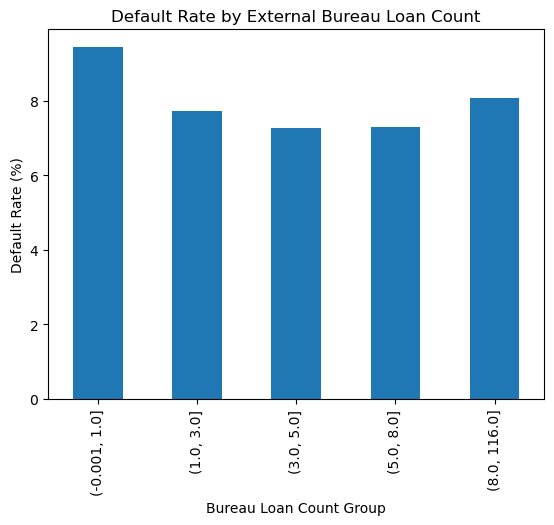

In [55]:
application_enriched['bureau_loan_group'] = pd.qcut(
    application_enriched['bureau_loan_count'],
    q=5,
    duplicates='drop'
)

bureau_risk = application_enriched.groupby('bureau_loan_group')['TARGET'].mean() * 100

bureau_risk.plot(kind='bar')
plt.title('Default Rate by External Bureau Loan Count')
plt.ylabel('Default Rate (%)')
plt.xlabel('Bureau Loan Count Group')
plt.show()

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\2472254830.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_enriched['previous_app_group'] = pd.qcut(


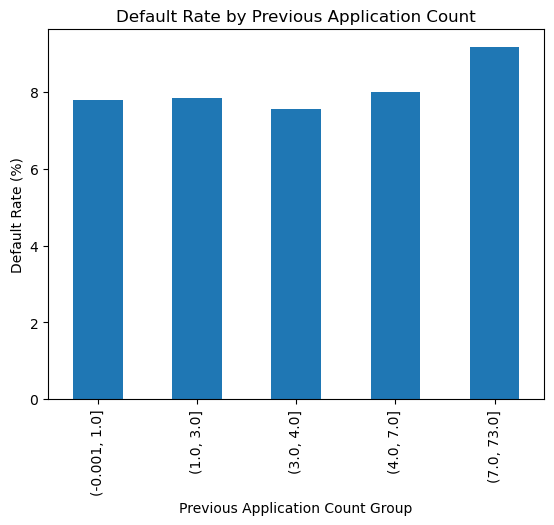

In [56]:
application_enriched['previous_app_group'] = pd.qcut(
    application_enriched['previous_application_count'],
    q=5,
    duplicates='drop'
)

previous_app_risk = application_enriched.groupby('previous_app_group')['TARGET'].mean() * 100

previous_app_risk.plot(kind='bar')
plt.title('Default Rate by Previous Application Count')
plt.ylabel('Default Rate (%)')
plt.xlabel('Previous Application Count Group')
plt.show()

In [57]:
application_enriched['income_per_person'] = (
    application_enriched['AMT_INCOME_TOTAL'] /
    application_enriched['CNT_FAM_MEMBERS']
)

C:\Users\15712\AppData\Local\Temp\ipykernel_42684\2588302953.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  application_enriched['income_per_person'] = (


## Relational Data Analysis

To extend the analysis beyond the primary application table, additional customer-level features were created from the `bureau` and `previous_application` datasets.

The `bureau` table contains information about customers' credit history with external financial institutions, while the `previous_application` table records prior loan applications submitted to Home Credit. Both datasets were aggregated using `SK_ID_CURR` and merged with the main application dataset to create customer-level behavioral features.

### External Bureau Loan History

Customers were grouped based on the number of loans reported in the Credit Bureau.

**Findings:**
- Applicants with only 0–1 bureau loans showed the highest default rate (~9.5%).
- Default rates declined for customers with 3–8 bureau loans (~7.3%–7.8%).
- Applicants with the largest number of bureau loans (8–116) showed a slightly higher default rate (~8.1%).

This suggests that limited credit history may be associated with elevated credit risk, while borrowers with moderate credit experience generally exhibited lower default rates.

### Previous Application History

Customers were also grouped according to the number of previous loan applications submitted to Home Credit.

**Findings:**
- Applicants with 0–7 previous applications had relatively similar default rates (~7.6%–8.0%).
- Customers with the highest application counts (7–73 prior applications) demonstrated the highest default rate (~9.2%).

This pattern may indicate that frequent borrowing activity is associated with increased credit risk, particularly among applicants with extensive application histories.

### Business Interpretation

The analysis demonstrates the value of combining multiple relational datasets to enrich customer profiles. While demographic factors such as education, age, and income provided useful insights, historical borrowing behavior from external credit records and prior lending activity offered additional signals related to default risk.

This approach mirrors real-world credit risk analytics, where information is integrated across multiple data sources to support lending decisions and risk assessment.

## Data Preparation for Modeling

In [58]:
model_features = [
    'age',
    'years_employed',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'loan_income_ratio',
    'annuity_income_ratio',
    'income_per_person',
    'bureau_loan_count',
    'active_loan_count',
    'closed_loan_count',
    'total_external_credit',
    'previous_application_count',
    'approved_application_count',
    'refused_application_count'
]

X = application_enriched[model_features]
y = application_enriched['TARGET']

In [59]:
#Checking for missing values
X.isnull().sum()[X.isnull().sum() > 0]

years_employed          55374
AMT_ANNUITY                12
annuity_income_ratio       12
income_per_person           2
dtype: int64

In [60]:
X = X.fillna(X.median())

In [61]:
X.isnull().sum()[X.isnull().sum() > 0]

Series([], dtype: int64)

Missing values in the modeling dataset were handled using median imputation. This was appropriate because the selected features were numeric and median values are less sensitive to outliers than mean values.

### Class Imbalance Consideration

The target variable was highly imbalanced, with approximately 92% non-default cases and 8% default cases. Because of this imbalance, model evaluation will focus on Recall, Precision, F1-Score, and ROC-AUC rather than Accuracy alone. Additionally, class weights will be used during model training to improve identification of default cases.

In [62]:
y.value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

In [63]:
y.value_counts(normalize=True) * 100

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64

In [64]:
from sklearn.model_selection import train_test_split

#Split data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [65]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(246008, 15)
(61503, 15)
(246008,)
(61503,)


In [66]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


## Logistic Regression (Class Weight Balanced)

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Modeling Dataset

The final modeling dataset includes applicant demographics, income and loan burden features, employment history, and aggregated credit history features from the relational tables.

In [68]:
from sklearn.linear_model import LogisticRegression

#Train data

log_model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42
)

log_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [69]:
y_pred_log = log_model.predict(X_test_scaled)

y_prob_log = log_model.predict_proba(X_test_scaled)[:,1]

In [70]:
from sklearn.metrics import classification_report

#Classification Report

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.95      0.61      0.74     56538
           1       0.12      0.61      0.20      4965

    accuracy                           0.61     61503
   macro avg       0.53      0.61      0.47     61503
weighted avg       0.88      0.61      0.70     61503



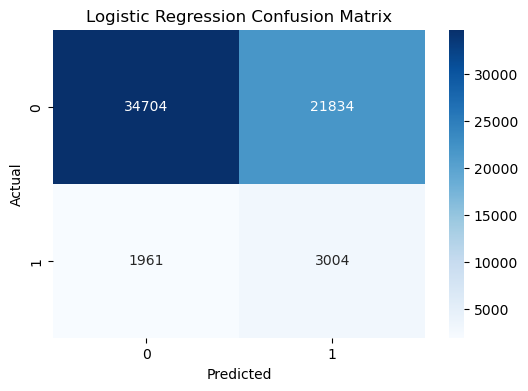

In [71]:
#Confusion Matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

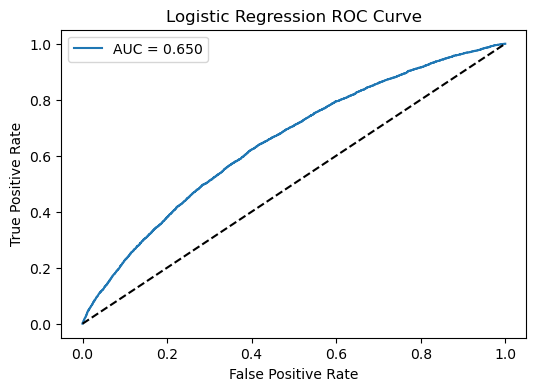

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

auc_score = roc_auc_score(y_test, y_prob_log)

plt.figure(figsize=(6,4))

plt.plot(
    fpr,
    tpr,
    label=f'AUC = {auc_score:.3f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')

plt.legend()

plt.show()

## Logistic Regression Results

A Logistic Regression model was trained using balanced class weights to address the imbalanced target variable.

The model achieved a Recall of 61% for default cases, indicating that it successfully identified a majority of high-risk applicants. However, Precision was relatively low (12%), suggesting that many applicants predicted as defaults ultimately did not default.

The ROC-AUC score of 0.65 indicates modest predictive power and suggests that credit risk is influenced by a combination of factors rather than a single dominant variable.

Because the business objective is to identify potentially risky borrowers, Recall was prioritized over Accuracy.

## Random Forest Model

A Random Forest model was trained as a second model comparison. Class weights were used to account for the imbalanced default target.

In [73]:
from sklearn.ensemble import RandomForestClassifier

#Train Random Forest

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [74]:
#Predictions
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

In [75]:
#Classidication Report 
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96     56538
           1       0.50      0.00      0.00      4965

    accuracy                           0.92     61503
   macro avg       0.71      0.50      0.48     61503
weighted avg       0.89      0.92      0.88     61503



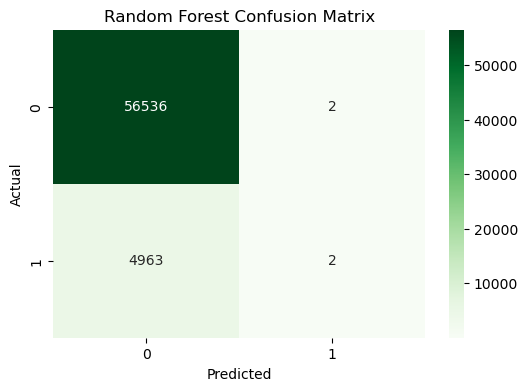

In [76]:
#Confusion Matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

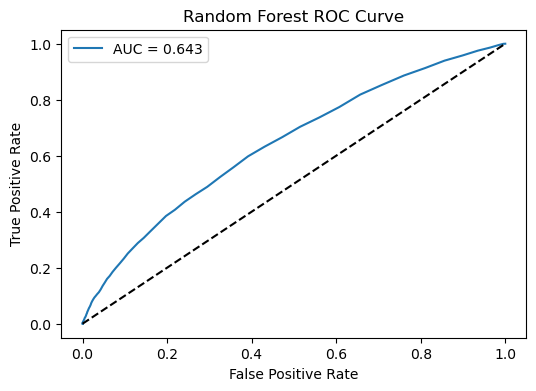

In [77]:
#ROC CURVE
from sklearn.metrics import roc_curve, roc_auc_score

fpr_rf, tpr_rf, thresholds_rf = roc_curve(
    y_test,
    y_prob_rf
)

auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(6,4))

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'AUC = {auc_rf:.3f}'
)

plt.plot([0,1],[0,1],'k--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.title('Random Forest ROC Curve')

plt.legend()

plt.show()

In [78]:
#Feature Importance 
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance.head(10)

age                           0.111454
years_employed                0.104563
annuity_income_ratio          0.092434
AMT_ANNUITY                   0.091599
loan_income_ratio             0.089971
AMT_CREDIT                    0.087551
total_external_credit         0.084223
income_per_person             0.069737
AMT_INCOME_TOTAL              0.054480
previous_application_count    0.045519
dtype: float64

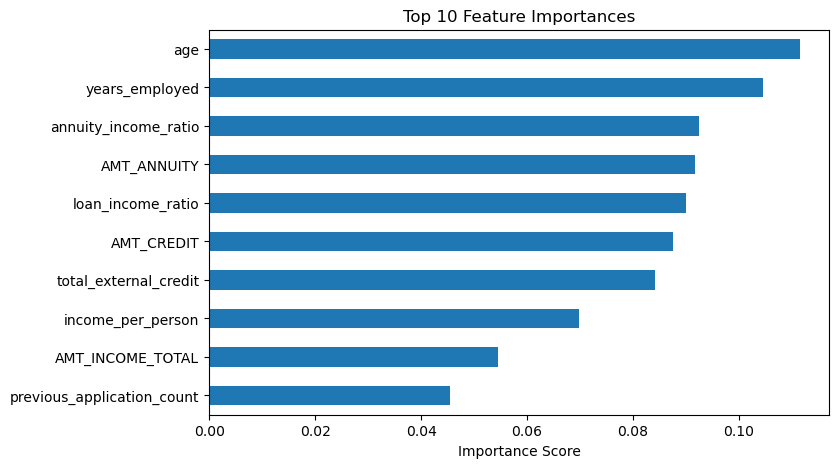

In [79]:
feature_importance.head(10).sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title('Top 10 Feature Importances')
plt.xlabel('Importance Score')
plt.show()

Feature importance analysis revealed that applicant age and employment history were the strongest predictors of credit risk. Debt burden metrics such as annuity-to-income ratio and loan size also played a significant role. External credit exposure and previous credit applications provided additional predictive value, suggesting that both financial capacity and historical borrowing behavior influence default risk.

## Model Comparison

| Metric | Logistic Regression | Random Forest |
|---|---:|---:|
| Accuracy | 0.61 | 0.92 |
| Recall (Default) | 0.61 | 0.00 |
| Precision (Default) | 0.12 | 0.50 |
| F1-Score (Default) | 0.20 | 0.00 |
| ROC-AUC | 0.650 | 0.643 |

Although Random Forest achieved higher overall accuracy (92%), it failed to identify defaulting applicants, resulting in near-zero recall for the target class. Logistic Regression achieved substantially higher recall (61%), making it more suitable for credit risk screening where identifying potential defaults is more important than maximizing overall accuracy.

# Tableau Dashboard Export

The enriched dataset was exported for Tableau to create an interactive credit risk dashboard.

In [ ]:
tableau_cols = [
    'SK_ID_CURR',
    'TARGET',
    'age',
    'years_employed',
    'income_group',
    'employment_group',
    'age_group',
    'annuity_group',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'AMT_INCOME_TOTAL',
    'AMT_CREDIT',
    'AMT_ANNUITY',
    'loan_income_ratio',
    'annuity_income_ratio',
    'income_per_person',
    'bureau_loan_count',
    'active_loan_count',
    'closed_loan_count',
    'total_external_credit',
    'previous_application_count',
    'approved_application_count',
    'refused_application_count'
]

tableau_df = application_enriched[tableau_cols]

tableau_df.to_csv('home_credit_tableau.csv', index=False)

## TABLEAU LINK https://public.tableau.com/app/profile/jordan.baldoceda.pizarro/viz/HomeCreditDefaultRiskAnalytics/CreditRiskAnalyticsDashboard